# County-level Energy Burden Modeling 

In [126]:
# load -> preprocess/merge -> split (grouped) -> PCA -> baseline models -> tune best -> SHAP -> exploratory analysis
#load packages
import os
import re
import time
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import requests

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline as SkPipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import shap
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)

 Configuration

In [128]:
# load data
NRI_PATH = "NRI_Table_Counties/NRI_Table_Counties.csv"
ENERGY_PATH = "energy_profile.csv"

# energy profile had some misc/ empty headers so adjusting the data
ENERGY_HEADER = 3
ENERGY_COL_INDEX = {
    "FIPS": 3,                
    "COUNTY_NAME": 1,         
    "RES_ELEC_EXPK": 15,      
    "RES_GAS_EXPK": 20,       
    "RES_HOUSEHOLDS": 24      
}

# acs definitions
ACS_YEAR = "2021"
ACS_DATASET = "acs/acs5"
ACS_VARIABLES: Dict[str, str] = {
    "B01003_001E": "Total_Population",
    "B19013_001E": "Median_Household_Income",
    "B02001_002E": "White_Alone",
    "B02001_003E": "Black_AA_Alone",
    "B02001_004E": "AIAN_Alone",
    "B02001_005E": "Asian_Alone",
    "B02001_006E": "NHOPI_Alone",
    "B03003_003E": "Hispanic_Latino",
}

In [168]:
# target definition
TARGET = "Energy_Burden_Pct"  # Options: "Energy_Burden_Pct" or "Avg_Energy_Cost_$"

# pca settings used inside pipelines
PCA_N_COMPONENTS = 0.95  

# split cv
GROUP_COL = "STATEFP"

RANDOM_STATE = 42
TEST_SIZE = 0.20

# candidate feature columns 
NRI_FEATURE_COLS = [
    "WNTW_RISKV",
    "WNTW_EALS",
    "SOVI_SCORE",
    "RESL_SCORE",
]

# define models
MODELS = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        n_jobs=-1,
    ),
}

# hyperparameter search 
RF_SEARCH_SPACE = {
    "model__n_estimators": [300, 600, 1000],
    "model__max_depth": [None, 6, 10, 16, 24],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

XGB_SEARCH_SPACE = {
    "model__n_estimators": [400, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 6, 8],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

## 1) Definitions/ helpers

In [170]:
# functions
def _require_file(path: str) -> None:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

def _as_fips(x) -> str:
    # county fips is 5 digits state is first 2 digits
    if pd.isna(x):
        return np.nan
    s = str(int(float(x))) if re.fullmatch(r"\d+(\.0+)?", str(x).strip()) else str(x).strip()
    s = re.sub(r"\D", "", s)
    return s.zfill(5) if s else np.nan

def load_nri(nri_path: str) -> pd.DataFrame:
    _require_file(nri_path)
    df = pd.read_csv(nri_path)
    # Standardize to 'FIPS'
    if "FIPS" not in df.columns:
        if "STCOFIPS" in df.columns:
            df = df.rename(columns={"STCOFIPS": "FIPS"})
        else:
            raise ValueError("NRI file must contain 'FIPS' or 'STCOFIPS' column.")
    df["FIPS"] = df["FIPS"].apply(_as_fips)
    df = df.dropna(subset=["FIPS"]).drop_duplicates(subset=["FIPS"])
    return df

def load_energy(energy_path: str, header: int, col_index: Dict[str, int]) -> pd.DataFrame:
    _require_file(energy_path)
    df_raw = pd.read_csv(energy_path, header=header)

    # pull required columns by index
    required = {
        "FIPS": df_raw.columns[col_index["FIPS"]],
        "county_name": df_raw.columns[col_index["COUNTY_NAME"]],
        "Res_Elec_Expend_k$": df_raw.columns[col_index["RES_ELEC_EXPK"]],
        "Res_Gas_Expend_k$": df_raw.columns[col_index["RES_GAS_EXPK"]],
        "Res_Households": df_raw.columns[col_index["RES_HOUSEHOLDS"]],
    }
    df = df_raw[list(required.values())].copy()
    df = df.rename(columns={v: k for k, v in required.items()})

    df["FIPS"] = df["FIPS"].apply(_as_fips)
    for c in ["Res_Elec_Expend_k$", "Res_Gas_Expend_k$", "Res_Households"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # convert expenditures from '000 $ to $
    df["Total_Res_Energy_Cost_$"] = (df["Res_Elec_Expend_k$"] + df["Res_Gas_Expend_k$"]) * 1000.0
    df["Avg_Energy_Cost_$"] = df["Total_Res_Energy_Cost_$"] / df["Res_Households"].replace(0, np.nan)

    df = df.dropna(subset=["FIPS"]).drop_duplicates(subset=["FIPS"])
    return df

def fetch_acs_county(year: str, dataset: str, variables: Dict[str, str], api_key: Optional[str] = None) -> pd.DataFrame:
    base_url = f"https://api.census.gov/data/{year}/{dataset}"
    var_list = list(variables.keys())
    get_vars = ",".join(var_list + ["NAME"])
    params = {"get": get_vars, "for": "county:*"}
    if api_key:
        params["key"] = api_key

    r = requests.get(base_url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    header = data[0]
    rows = data[1:]
    df = pd.DataFrame(rows, columns=header)

    # convert and rename
    for v in var_list:
        df[v] = pd.to_numeric(df[v], errors="coerce")

    df = df.rename(columns=variables)

    # county fips
    df["state"] = df["state"].astype(str).str.zfill(2)
    df["county"] = df["county"].astype(str).str.zfill(3)
    df["FIPS"] = df["state"] + df["county"]
    df = df.drop(columns=["state", "county"])

    return df

def add_demographic_shares(df: pd.DataFrame) -> pd.DataFrame:
    pop = df["Total_Population"].replace(0, np.nan)
    df["Pct_White"] = df["White_Alone"] / pop
    df["Pct_Black"] = df["Black_AA_Alone"] / pop
    df["Pct_Asian"] = df["Asian_Alone"] / pop
    df["Pct_Hispanic"] = df["Hispanic_Latino"] / pop
    df["Pct_AIAN"] = df["AIAN_Alone"] / pop
    df["Pct_NHOPI"] = df["NHOPI_Alone"] / pop
    return df

def make_pipeline_for_features(model, feature_cols: List[str]) -> Pipeline:
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_STATE)),
    ])
    preprocessor = ColumnTransformer(
        transformers=[("num", numeric_transformer, feature_cols)],
        remainder="drop"
    )
    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

## 2) Preprocess and merge

In [172]:
#pre process and merge data
nri_df = load_nri(NRI_PATH)
energy_df = load_energy(ENERGY_PATH, header=ENERGY_HEADER, col_index=ENERGY_COL_INDEX)

# acs data via api
ACS_CACHE = f"acs_county_{ACS_YEAR}.csv"
if os.path.exists(ACS_CACHE):
    census_df = pd.read_csv(ACS_CACHE)
else:
    census_df = fetch_acs_county(
        year=ACS_YEAR,
        dataset=ACS_DATASET,
        variables=ACS_VARIABLES,
        api_key=os.getenv("CENSUS_API_KEY")
    )
    census_df.to_csv(ACS_CACHE, index=False)

In [174]:
# fips
census_df["FIPS"] = census_df["FIPS"].apply(_as_fips)

# merge via inner join
df = nri_df.merge(energy_df, on="FIPS", how="inner").merge(census_df, on="FIPS", how="inner")
df["STATEFP"] = df["FIPS"].str[:2]

df = add_demographic_shares(df)

# target
df["Energy_Burden_Pct"] = 100.0 * df["Avg_Energy_Cost_$"] / df["Median_Household_Income"]

#filter
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET, "Median_Household_Income", "Avg_Energy_Cost_$"])
df = df[df["Median_Household_Income"] > 0]
df = df[df["Avg_Energy_Cost_$"] >= 0]

print("dataset shape:", df.shape)
df[[ "FIPS", "STATEFP", "Avg_Energy_Cost_$", "Median_Household_Income", "Energy_Burden_Pct" ]].head()

dataset shape: (75, 488)


,FIPS,STATEFP,Avg_Energy_Cost_$,Median_Household_Income,Energy_Burden_Pct
71,02060,02,1369.444444,81563,1.679002
76,02105,02,1172.248804,55990,2.093675
82,02164,02,1444.444444,49688,2.907029
90,02230,02,1373.831776,75000,1.831776
93,02282,02,1376.518219,72083,1.909629


## 3) Define features and target

In [176]:
#feature matrix

missing_nri = [c for c in NRI_FEATURE_COLS if c not in df.columns]
if missing_nri:
    raise ValueError(f"Missing NRI columns in merged data: {missing_nri}")

demo_cols = [
    "Total_Population",
    "Median_Household_Income",
    "Pct_White",
    "Pct_Black",
    "Pct_Asian",
    "Pct_Hispanic",
    "Pct_AIAN",
    "Pct_NHOPI",
]

feature_cols = NRI_FEATURE_COLS + demo_cols

missing_feat = [c for c in feature_cols if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing feature columns: {missing_feat}")

X = df[feature_cols].copy()
y = df[TARGET].copy()
groups = df[GROUP_COL].copy()

print("Features:", feature_cols)
print("X shape:", X.shape, "y shape:", y.shape, "n_groups:", groups.nunique())

Features: ['WNTW_RISKV', 'WNTW_EALS', 'SOVI_SCORE', 'RESL_SCORE', 'Total_Population', 'Median_Household_Income', 'Pct_White', 'Pct_Black', 'Pct_Asian', 'Pct_Hispanic', 'Pct_AIAN', 'Pct_NHOPI']
X shape: (75, 12) y shape: (75,) n_groups: 17


## 4) Train/test split (grouped by state)

In [178]:
# train test split
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train = groups.iloc[train_idx]

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train states:", g_train.nunique(), "Test states:", groups.iloc[test_idx].nunique())

# okay clearly something is wrong here....

Train size: 50 Test size: 25
Train states: 13 Test states: 4


## 5) PCA 

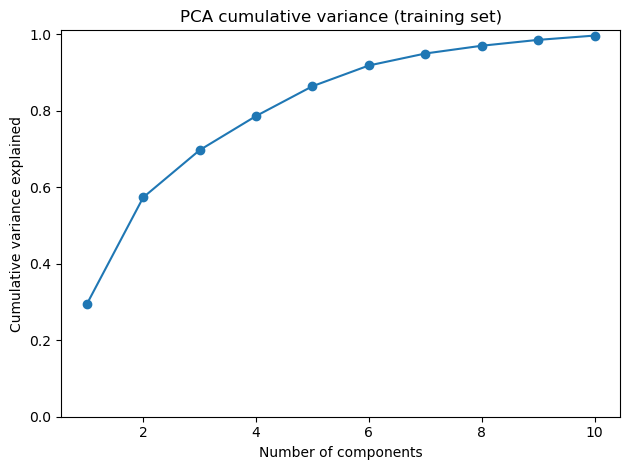

,PC1,PC2,PC3,PC4,PC5
Pct_NHOPI,0.514639,-0.049121,-0.027617,0.040582,-0.027408
Pct_Asian,0.507229,-0.064073,-0.058326,0.057626,0.030776
Pct_AIAN,0.478716,-0.082768,0.022248,-0.039058,-0.033239
Pct_White,-0.373411,-0.296176,-0.309736,0.004186,0.030481
RESL_SCORE,0.189328,-0.303641,0.182866,-0.183305,0.265347
Median_Household_Income,0.151688,-0.441389,-0.017715,-0.129029,0.037033
WNTW_EALS,-0.140127,-0.348150,0.466187,0.101243,-0.241554
Total_Population,-0.119090,-0.054367,0.338725,-0.489202,0.662093
Pct_Hispanic,0.080435,0.315581,0.153935,-0.605196,-0.426780
WNTW_RISKV,-0.071554,-0.266833,0.559724,0.138440,-0.355896


In [180]:
# pca on training

pca_explore = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=min(len(feature_cols), 10), random_state=RANDOM_STATE)),
])

_ = pca_explore.fit(X_train)
explained = pca_explore.named_steps["pca"].explained_variance_ratio_

plt.figure()
plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.title("PCA cumulative variance (training set)")
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

pc_names = [f"PC{i+1}" for i in range(pca_explore.named_steps["pca"].components_.shape[0])]
loadings_explore = pd.DataFrame(
    pca_explore.named_steps["pca"].components_.T,
    index=feature_cols,
    columns=pc_names
)
loadings_explore.iloc[:, :5].sort_values("PC1", key=lambda s: np.abs(s), ascending=False).head(15)

## 6) Baseline models 

In [182]:
#baseline models w cv
cv = GroupKFold(n_splits=5)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

baseline_results = []
pipelines = {}

for name, model in MODELS.items():
    pipe = make_pipeline_for_features(model, feature_cols)
    pipelines[name] = pipe

    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        groups=g_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )
    baseline_results.append({
        "model": name,
        "cv_MAE": -np.mean(cv_out["test_MAE"]),
        "cv_RMSE": -np.mean(cv_out["test_RMSE"]),
        "cv_R2": np.mean(cv_out["test_R2"]),
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("cv_R2", ascending=False)
baseline_df

,model,cv_MAE,cv_RMSE,cv_R2
2,XGBoost,0.771225,1.029137,-0.873926
1,RandomForest,0.831229,1.112975,-1.208979
0,Ridge,1.748033,4.040161,-29.771991


## 7) Compare models

In [184]:
test_results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    test_results.append({
        "model": name,
        "test_MAE": mean_absolute_error(y_test, preds),
        "test_RMSE": mean_squared_error(y_test, preds, squared=False),
        "test_R2": r2_score(y_test, preds),
    })

test_df = pd.DataFrame(test_results).sort_values("test_R2", ascending=False)
test_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,model,test_MAE,test_RMSE,test_R2
1,RandomForest,0.578225,0.756372,0.305321
2,XGBoost,0.643744,0.864680,0.092130
0,Ridge,0.887575,1.230681,-0.839094


## 8) Tuning

In [186]:
# tune best model

best_name = baseline_df.iloc[0]["model"]
best_pipe = pipelines[best_name]
print("Best baseline model (by CV R2):", best_name)

if best_name == "RandomForest":
    search_space = RF_SEARCH_SPACE
elif best_name == "XGBoost":
    search_space = XGB_SEARCH_SPACE
else:
    search_space = {"model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]}

search = RandomizedSearchCV(
    estimator=best_pipe,
    param_distributions=search_space,
    n_iter=40,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

search.fit(X_train, y_train, groups=g_train)

print("Best params:", search.best_params_)
print("Best CV R2:", search.best_score_)

best_model = search.best_estimator_

Best baseline model (by CV R2): XGBoost
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 0.5, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
Best CV R2: -0.4882220635226514


## 9) Final eval

In [187]:
final_preds = best_model.predict(X_test)

final_metrics = {
    "model": best_name,
    "MAE": mean_absolute_error(y_test, final_preds),
    "RMSE": mean_squared_error(y_test, final_preds, squared=False),
    "R2": r2_score(y_test, final_preds),
}
final_metrics

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'model': 'XGBoost',
 'MAE': 0.5580639542623141,
 'RMSE': 0.7286744464351381,
 'R2': 0.35526633953092435}

## 10) SHAP and PCA loadings

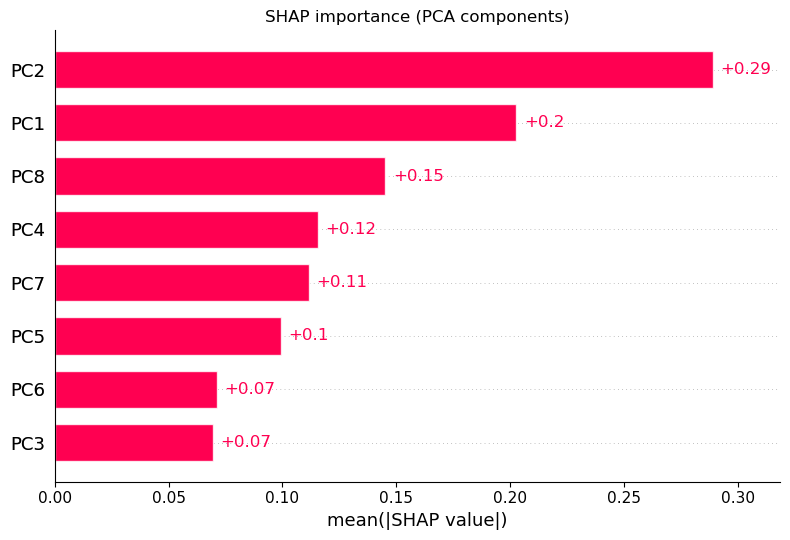

In [190]:
#shap 
pre = best_model.named_steps["preprocess"]
pca = pre.named_transformers_["num"].named_steps["pca"]

X_train_pca = pre.transform(X_train)
X_test_pca = pre.transform(X_test)

pc_names = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=pc_names
)

underlying = best_model.named_steps["model"]

bg = shap.sample(pd.DataFrame(X_train_pca, columns=pc_names), 200, random_state=RANDOM_STATE)
X_eval = pd.DataFrame(X_test_pca, columns=pc_names)

explainer = shap.Explainer(underlying, bg)
shap_values = explainer(X_eval)

plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP importance (PCA components)")
plt.tight_layout()
plt.show()

In [192]:
# top original features for PC
mean_abs = np.abs(shap_values.values).mean(axis=0)
top_pc_idx = np.argsort(mean_abs)[::-1][:5]
top_pcs = [pc_names[i] for i in top_pc_idx]

def top_loadings_for_pc(pc: str, k: int = 10) -> pd.DataFrame:
    s = loadings[pc].sort_values(key=lambda x: np.abs(x), ascending=False)
    return s.head(k).to_frame("loading")

for pc in top_pcs:
    display(top_loadings_for_pc(pc, k=10))

,loading
SOVI_SCORE,0.473752
Median_Household_Income,-0.441389
WNTW_EALS,-0.348150
Pct_Hispanic,0.315581
Pct_Black,0.304125
RESL_SCORE,-0.303641
Pct_White,-0.296176
WNTW_RISKV,-0.266833
Pct_AIAN,-0.082768
Pct_Asian,-0.064073


,loading
Pct_NHOPI,0.514639
Pct_Asian,0.507229
Pct_AIAN,0.478716
Pct_White,-0.373411
RESL_SCORE,0.189328
Median_Household_Income,0.151688
WNTW_EALS,-0.140127
Total_Population,-0.119090
Pct_Hispanic,0.080435
WNTW_RISKV,-0.071554


,loading
WNTW_EALS,-0.686423
WNTW_RISKV,0.516033
Median_Household_Income,0.382247
SOVI_SCORE,0.249215
Pct_White,0.117675
RESL_SCORE,0.113895
Total_Population,-0.090399
Pct_Asian,-0.089748
Pct_NHOPI,-0.079643
Pct_Black,0.048418


,loading
Pct_Hispanic,-0.605196
Pct_Black,0.548966
Total_Population,-0.489202
RESL_SCORE,-0.183305
WNTW_RISKV,0.138440
Median_Household_Income,-0.129029
WNTW_EALS,0.101243
SOVI_SCORE,-0.082939
Pct_Asian,0.057626
Pct_NHOPI,0.040582


,loading
Median_Household_Income,0.721675
WNTW_RISKV,-0.308795
RESL_SCORE,-0.293806
Pct_Black,0.274443
Pct_Asian,-0.249141
Pct_White,-0.227304
Pct_NHOPI,-0.216045
Pct_Hispanic,0.150699
WNTW_EALS,0.134549
Pct_AIAN,0.116379


## 11) Exploratory analysis

In [194]:
# exploratory analysis on test data

df_test = df.iloc[test_idx].copy()
df_test["pred"] = final_preds
df_test["residual"] = df_test[TARGET] - df_test["pred"]

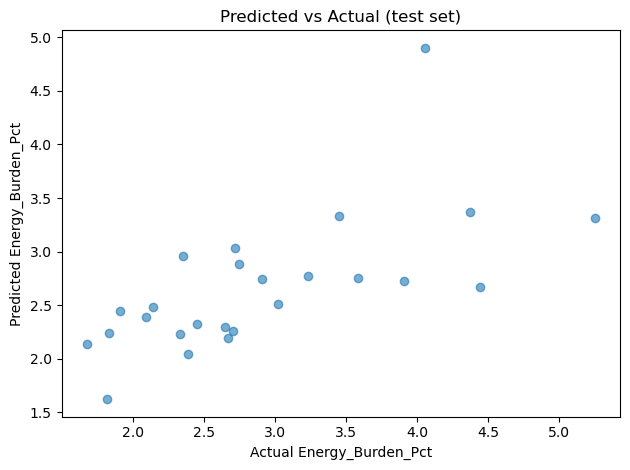

In [196]:
plt.figure()
plt.scatter(df_test[TARGET], df_test["pred"], alpha=0.6)
plt.xlabel(f"Actual {TARGET}")
plt.ylabel(f"Predicted {TARGET}")
plt.title("Predicted vs Actual (test set)")
plt.tight_layout()
plt.show()

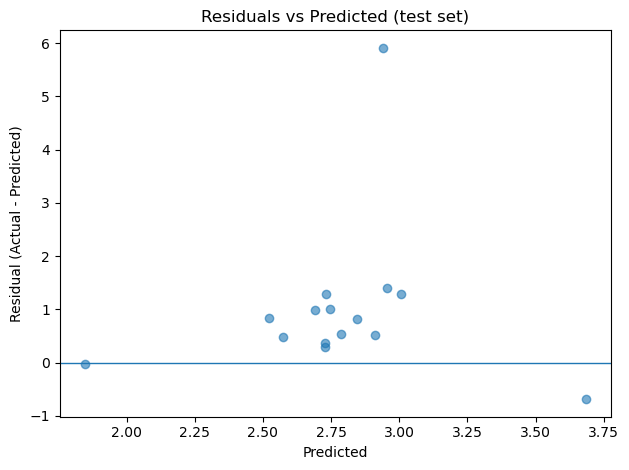

In [162]:
plt.figure()
plt.scatter(df_test["pred"], df_test["residual"], alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted (test set)")
plt.tight_layout()
plt.show()

In [198]:
cols_show = ["FIPS", "STATEFP", "county_name", TARGET, "pred", "residual", "Median_Household_Income", "Avg_Energy_Cost_$"]
available = [c for c in cols_show if c in df_test.columns]

print("Highest burden counties (test):")
display(df_test.sort_values(TARGET, ascending=False)[available].head(10))

Highest burden counties (test):


,FIPS,STATEFP,county_name,Energy_Burden_Pct,pred,residual,Median_Household_Income,Avg_Energy_Cost_$
2743,48443,48,TX,5.247962,3.317141,1.930821,47012,2467.171717
2599,48155,48,TX,4.440149,2.666381,1.773768,37679,1673.003802
2544,48045,48,TX,4.368493,3.367724,1.000770,38469,1680.515759
2652,48261,48,TX,4.056511,4.901448,-0.844937,42778,1735.294118
2572,48101,48,TX,3.910116,2.729442,1.180674,43654,1706.921944
2737,48431,48,TX,3.584943,2.755910,0.829034,55481,1988.962472
937,20101,20,KS,3.450838,3.336205,0.114632,44219,1525.925926
922,20071,20,KS,3.232249,2.774062,0.458187,57281,1851.464435
986,20199,20,KS,3.022194,2.511450,0.510745,56538,1708.688245
82,02164,02,AK,2.907029,2.743852,0.163177,49688,1444.444444


In [200]:
print("Lowest burden counties (test):")
display(df_test.sort_values(TARGET, ascending=True)[available].head(10))

by_state = df_test.groupby("STATEFP")[TARGET].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
by_state.head(15)

Lowest burden counties (test):


,FIPS,STATEFP,county_name,Energy_Burden_Pct,pred,residual,Median_Household_Income,Avg_Energy_Cost_$
71,02060,02,AK,1.679002,2.140692,-0.461689,81563,1369.444444
186,06003,06,CA,1.822157,1.624871,0.197287,96000,1749.271137
90,02230,02,AK,1.831776,2.238968,-0.407192,75000,1373.831776
93,02282,02,AK,1.909629,2.448037,-0.538408,72083,1376.518219
76,02105,02,AK,2.093675,2.389879,-0.296203,55990,1172.248804
2694,48345,48,TX,2.141271,2.483909,-0.342639,59286,1269.473684
2608,48173,48,TX,2.330763,2.231185,0.099578,85417,1990.867580
2656,48269,48,TX,2.353064,2.960384,-0.607320,42125,991.228070
2527,48011,48,TX,2.388988,2.042866,0.346122,71136,1699.430199
2701,48359,48,TX,2.451388,2.323639,0.127748,68077,1668.831169


,count,mean,median
STATEFP,,,
20,3,3.235094,3.232249
48,16,3.173262,2.714915
02,5,2.084222,1.909629
06,1,1.822157,1.822157
